In [1]:
%matplotlib inline

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch

root = Path.cwd()
if not (root / "src").is_dir():
    root = root.parent
sys.path.insert(0, str(root / "src"))

from experiments.long_rollout import run_long_comparison
from experiments.long_rollout_plots import (
    rollout_curves, kinetic_energy_curves, vorticity_constraints, failure_curves, failure_fraction,
)

if not torch.cuda.is_available():
    raise RuntimeError("Select a Python kernel with CUDA-enabled PyTorch and GPU access")
torch.set_num_threads(1)
plt.rcParams.update({"font.size": 10, "figure.dpi": 120})
print(f"Environment: {sys.prefix}; CUDA: {torch.cuda.get_device_name(0)}")

Environment: /home/scdlds_abhikrana/miniconda3/envs/research; CUDA: NVIDIA H100 NVL


In [2]:
output = root / "results" / "phfno_fno_long_rollout"
results = run_long_comparison(
    dataset_dir=root / "datasets" / "large",
    checkpoint_dirs={
        # Audit fix: load the current velocity comparison, whose checkpoint records the AVF protocol.
        "velocity": root / "results" / "local_smoke_test_seeds_8_18_28",
        "vorticity": root / "results" / "phfno_fno_vorticity",
    },
    output_dir=output,
    device="cuda",
)

print("Training state  Model  Seed  Selected step  Failed  First failure  t=20 velocity NRMSE")
for run in results["runs"]:
    metrics = [run["test"][family] for family in results["families"]]
    fractions = [failure_fraction(item) for item in metrics]
    failed_count = sum(round(fraction[-1] * item["nrmse_time"].shape[0])
                       for item, fraction in zip(metrics, fractions))
    failure_times = [float(item["times"][(fraction > 0).argmax()])
                     for item, fraction in zip(metrics, fractions) if fraction[-1] > 0]
    total = sum(item["nrmse_time"].shape[0] for item in metrics)
    first_failure = f"{min(failure_times):.3f}" if failure_times else "—"
    final_error = torch.cat([item["nrmse_time"][:, -1] for item in metrics]).mean()
    final_label = f"{final_error.item():.4g}" if torch.isfinite(final_error) else "failed"
    print(f"{run['representation']:<14}  {run['model']:<5}  {run['seed']:>4}"
          f"  {run['best_step']:>13}  {failed_count:>2}/{total:<2}"
          f"  {first_failure:>13}  {final_label:>19}")

Training state  Model  Seed  Selected step  Failed  First failure  t=20 velocity NRMSE
velocity        PHFNO     7           2800   0/12              —              0.04488
velocity        PHFNO    17           3000   0/12              —                0.149
velocity        PHFNO    27           3000   0/12              —               0.0805
velocity        FNO       7           2900   0/12              —              0.06084
velocity        FNO      17           2900   0/12              —              0.03653
velocity        FNO      27           2900   0/12              —               0.1035
vorticity       PHFNO     7           2900   7/12          5.150               failed
vorticity       PHFNO    17           1600  12/12         11.325               failed
vorticity       PHFNO    27           2900  10/12         11.050               failed
vorticity       FNO       7           2800   0/12              —            2.594e+04
vorticity       FNO      17           3000   0/12    

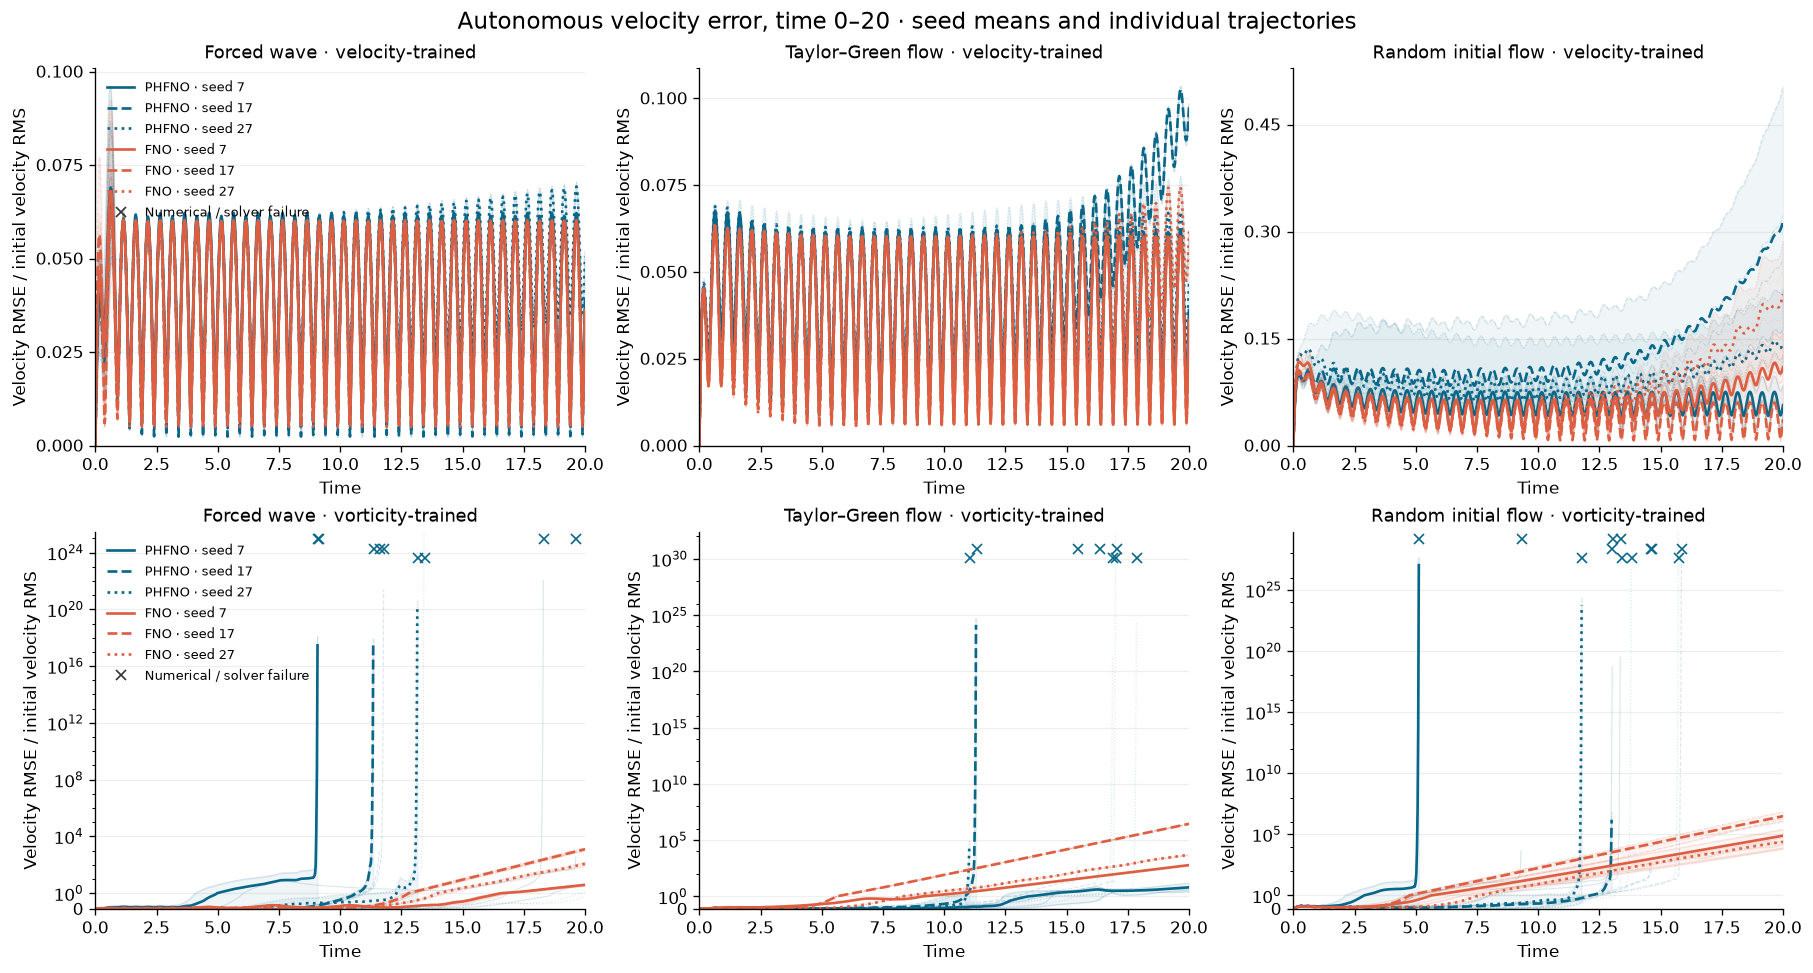

In [3]:
figure = rollout_curves(results)
figure.savefig(output / "velocity_rollout_error.png")
plt.show()

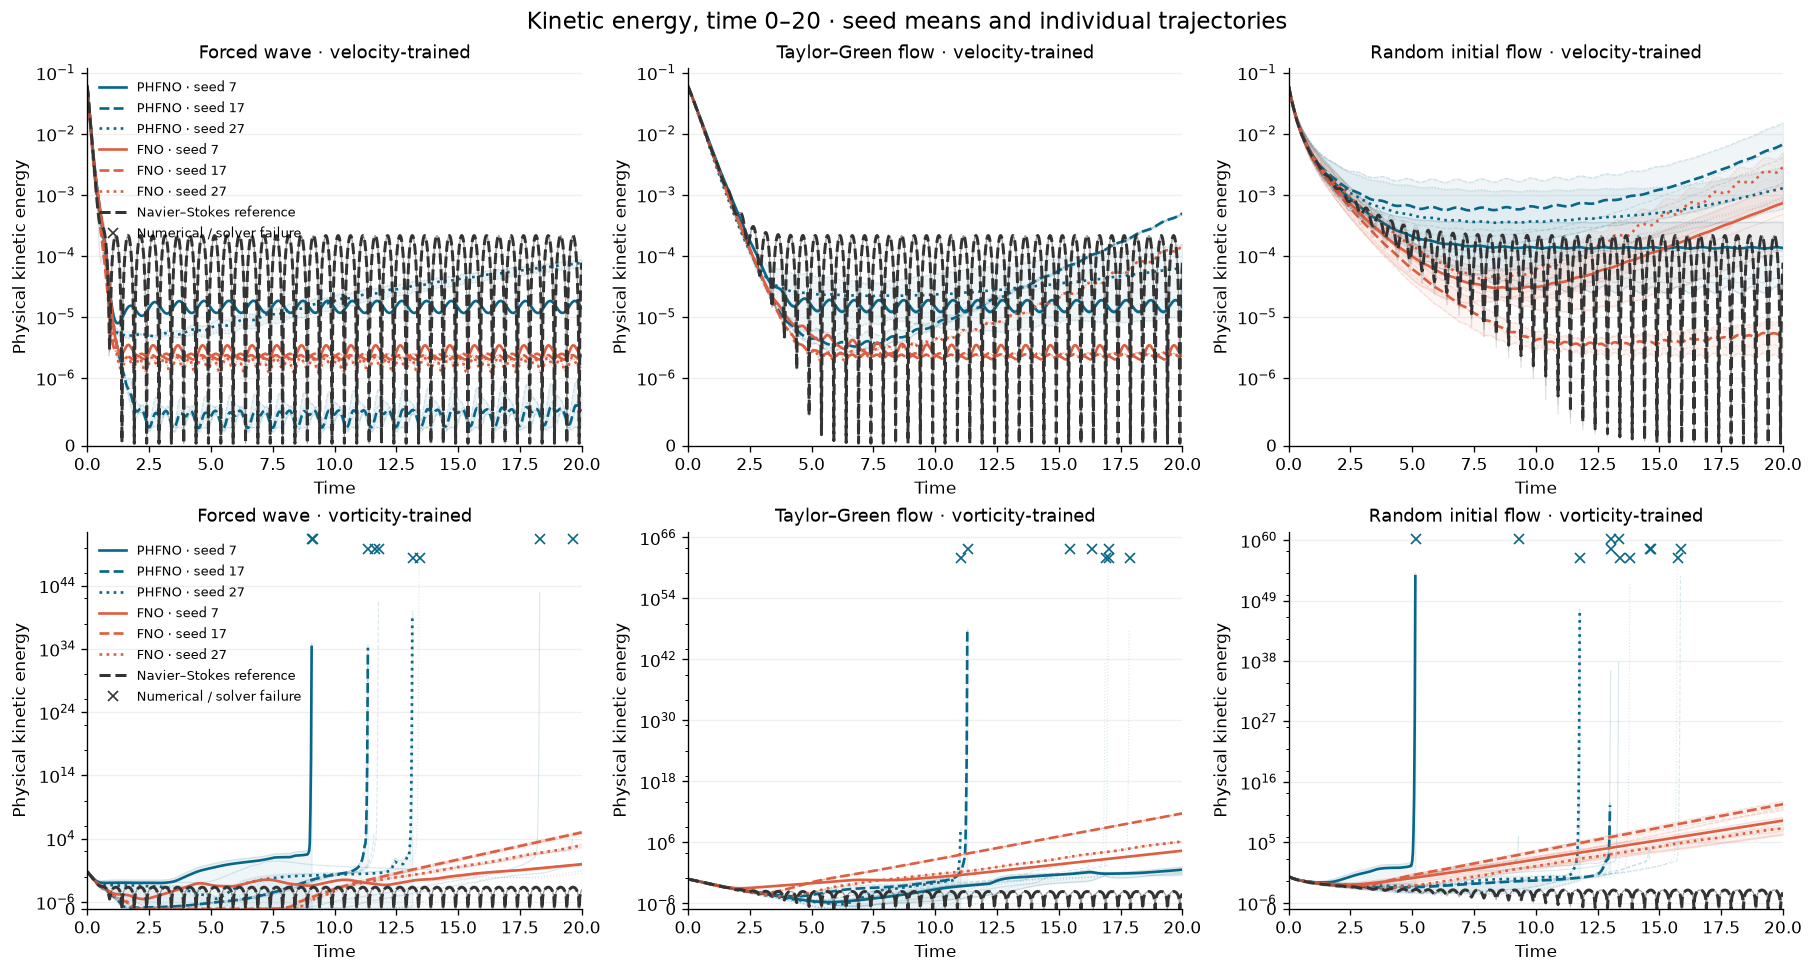

In [4]:
figure = kinetic_energy_curves(results)
figure.savefig(output / "kinetic_energy.png")
plt.show()

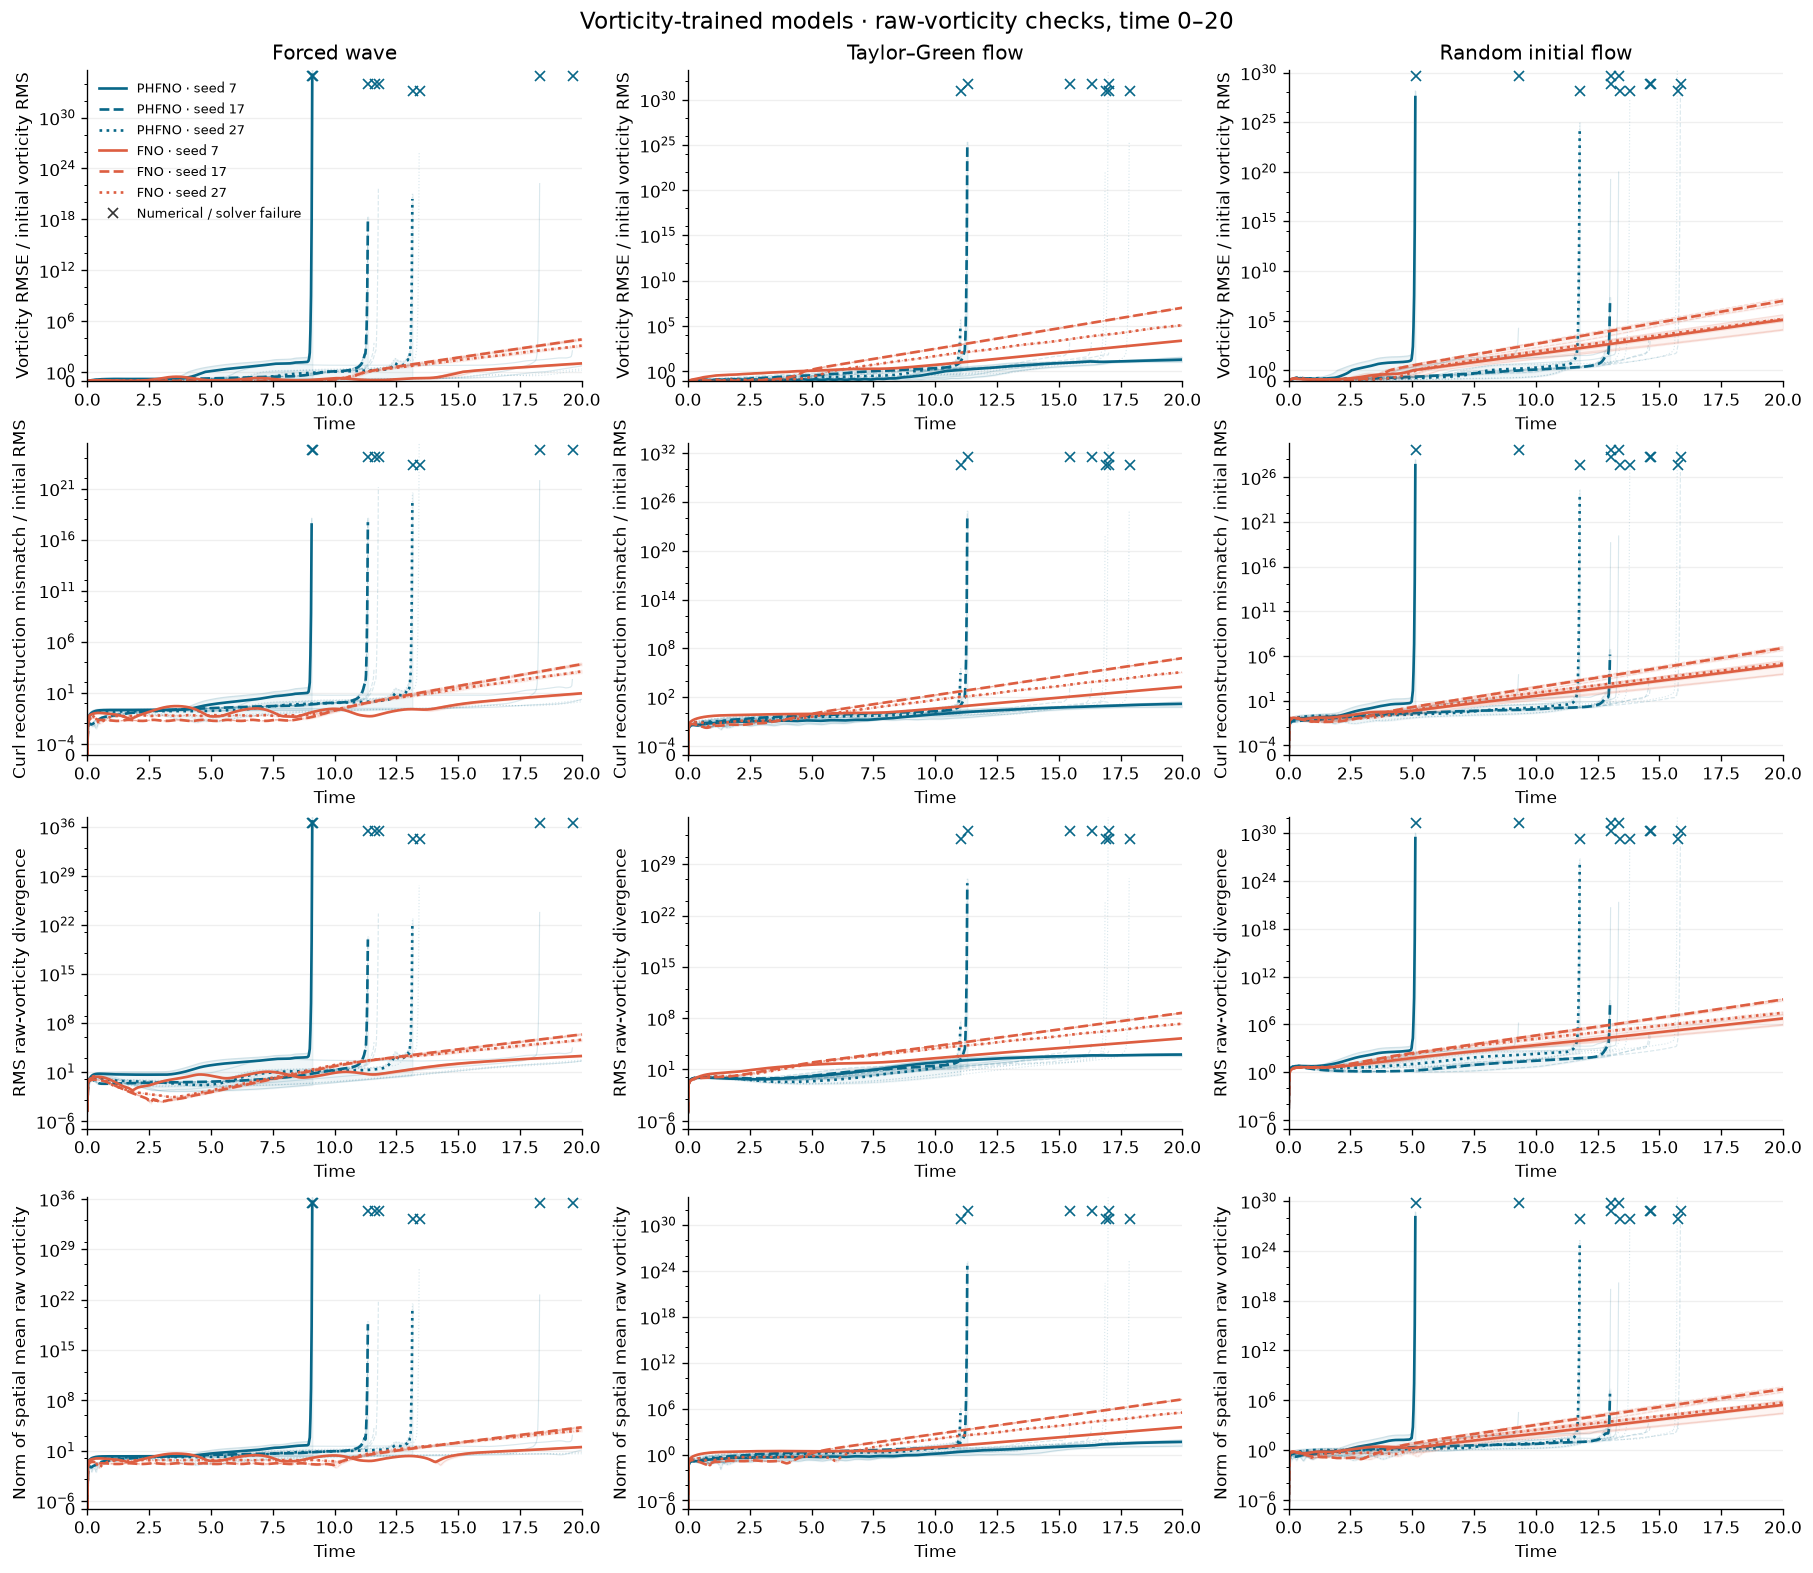

In [5]:
figure = vorticity_constraints(results)
figure.savefig(output / "raw_vorticity_checks.png")
plt.show()

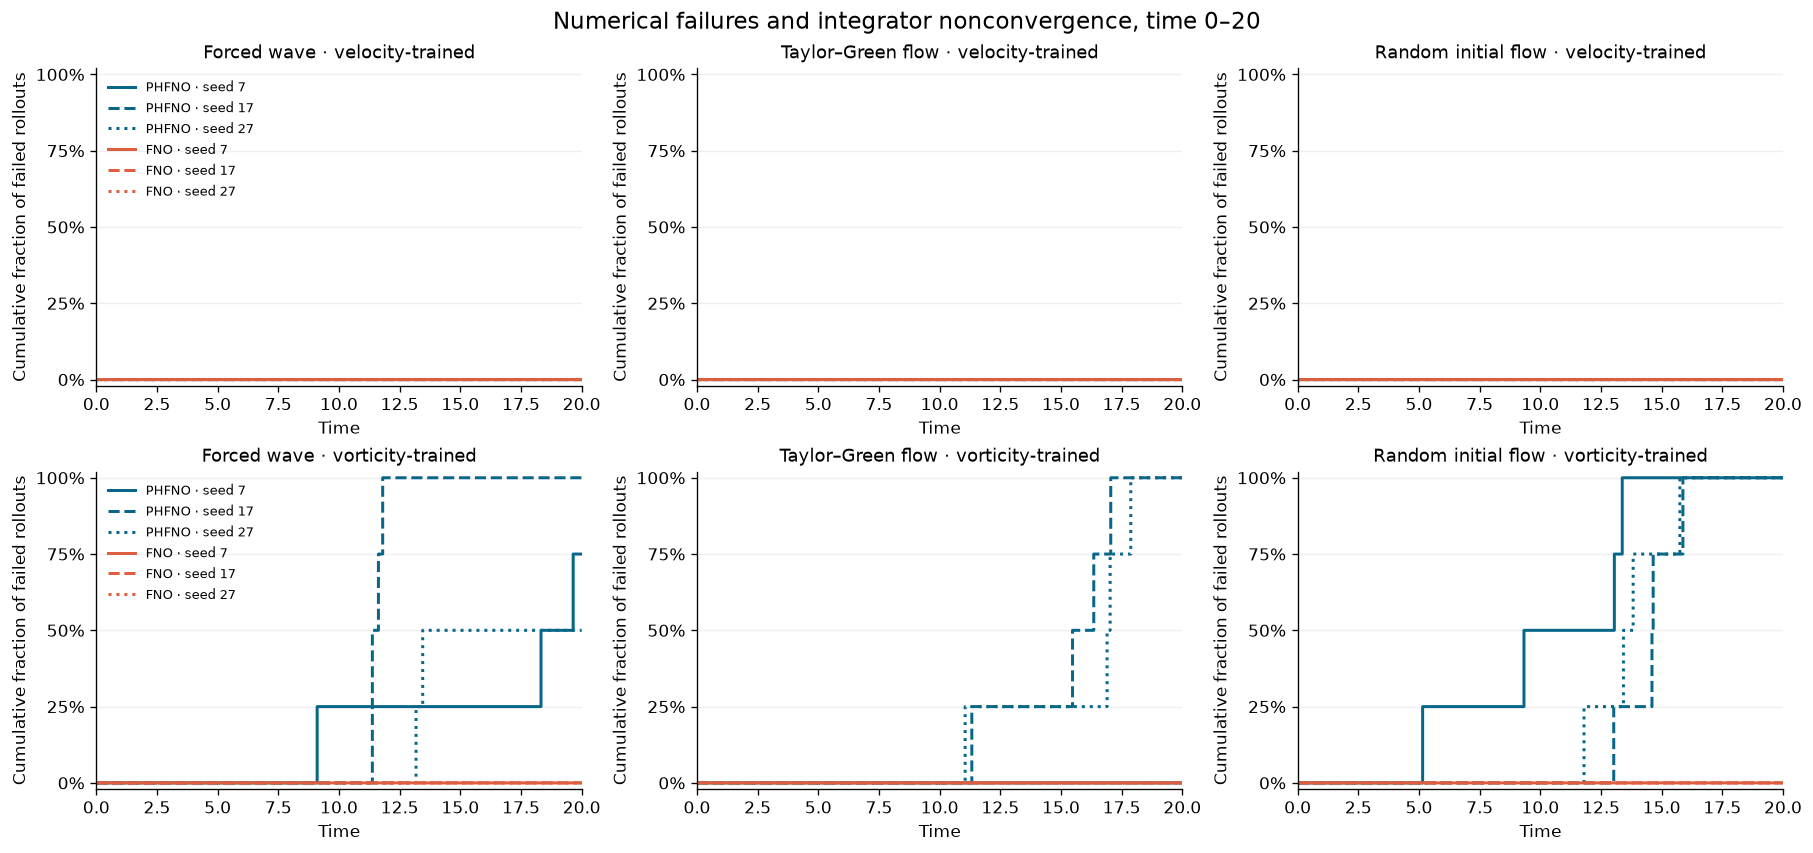

In [6]:
figure = failure_curves(results)
figure.savefig(output / "rollout_failures.png")
plt.show()